# Chapter 07 - Support Vector Machines
## Margin-Based Classification with Kernels
Based on scikit-learn Cookbook. This notebook explains Support Vector Machines (SVM), margins, kernels, and classification boundaries.

## Objective
Understand how SVM finds an optimal separating boundary with maximum margin and how kernels solve non-linear problems.

## Theory Introduction
Support Vector Machines aim to separate classes by finding a hyperplane that maximizes the margin between classes. The closest data points to the boundary are called support vectors.

A larger margin often improves generalization. For non-linear data, kernel functions transform data into higher-dimensional spaces where separation becomes easier.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
plt.style.use('ggplot')

## 1. Create Non-Linear Dataset

In [2]:
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. Visualize Dataset

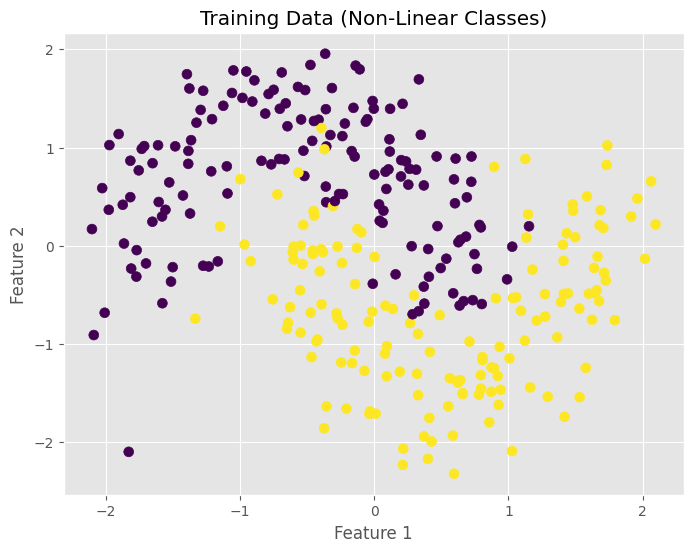

In [3]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=50)
plt.title('Training Data (Non-Linear Classes)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Description:** The classes are not linearly separable, making this dataset ideal for demonstrating kernel-based SVM.

## 3. Train Linear and RBF SVM

In [4]:
svm_linear = SVC(kernel='linear', C=1.0)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_linear.fit(X_train,y_train)
svm_rbf.fit(X_train,y_train)
pred_lin = svm_linear.predict(X_test)
pred_rbf = svm_rbf.predict(X_test)
acc_lin = accuracy_score(y_test,pred_lin)
acc_rbf = accuracy_score(y_test,pred_rbf)
print('Linear SVM Accuracy:', round(acc_lin,4))
print('RBF SVM Accuracy:', round(acc_rbf,4))

Linear SVM Accuracy: 0.92
RBF SVM Accuracy: 0.95


## 4. Accuracy Comparison

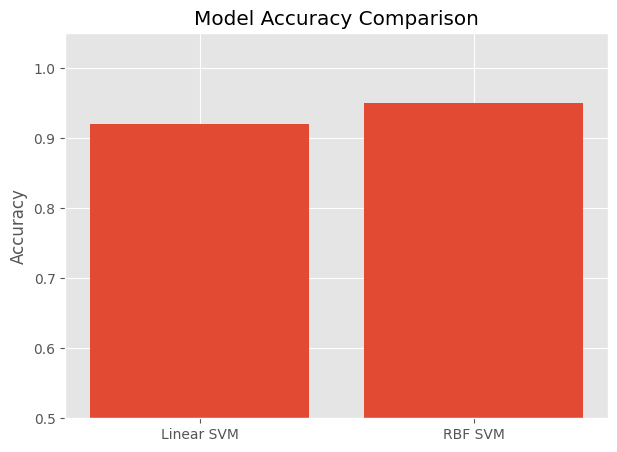

In [5]:
plt.figure(figsize=(7,5))
plt.bar(['Linear SVM','RBF SVM'], [acc_lin, acc_rbf])
plt.ylim(0.5,1.05)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

**Description:** Non-linear datasets often benefit from the RBF kernel because it can model curved decision boundaries.

## 5. Confusion Matrix (RBF Model)

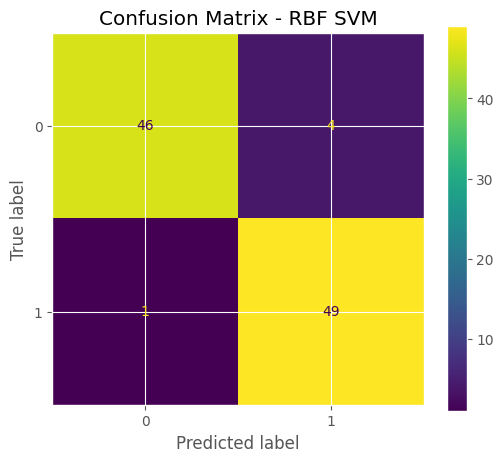

In [6]:
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test,pred_rbf,ax=ax)
plt.title('Confusion Matrix - RBF SVM')
plt.show()

**Description:** The confusion matrix summarizes correct and incorrect predictions for each class.

## 6. Decision Boundary (RBF Kernel)

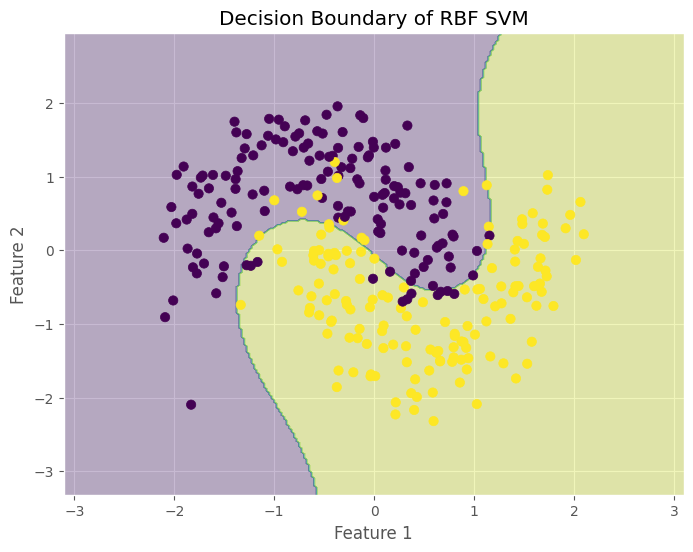

In [7]:
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min,x_max,250), np.linspace(y_min,y_max,250))
Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, s=45)
plt.title('Decision Boundary of RBF SVM')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Description:** The RBF kernel creates flexible non-linear boundaries that better separate moon-shaped classes.

## Important Theory Concepts
- **Margin:** Distance between decision boundary and nearest samples.
- **Support Vectors:** Critical points closest to the boundary.
- **Kernel Trick:** Implicit transformation into higher dimensions.
- **C Parameter:** Controls penalty for misclassification.
- **Gamma (RBF):** Controls influence range of each point.

## Interpretation of Results
Linear SVM may struggle on curved patterns, while RBF SVM usually performs better on non-linear datasets. Parameter tuning strongly affects performance.

## Summary
SVM is a powerful algorithm for both linear and non-linear classification. With proper kernels and tuning, it often delivers strong performance on medium-sized datasets.

## Conclusion
Use Linear SVM for simpler separable data and RBF SVM when class boundaries are complex or curved.